In [0]:
%python
order_df = spark.table('workspace.default.orders')
order_df.show(3)

+-------------+----------+----------+------------------+-----------+-----------+------+--------+------------+
|     Order_ID|Order_Date|Product_ID|      Product_Name|   Category|Subcategory|Region|Quantity|Sales_Amount|
+-------------+----------+----------+------------------+-----------+-----------+------+--------+------------+
|ORD-2026-0342|2026-01-01|      P106|Kajal Pencil Black|  Cosmetics|       Eyes| South|       2|         698|
|ORD-2026-0365|2026-01-01|      P201|  Wireless Earbuds|Electronics|      Audio| North|       1|        1999|
|ORD-2026-0372|2026-01-01|      P105|    Volume Mascara|  Cosmetics|       Eyes|  East|       1|         749|
+-------------+----------+----------+------------------+-----------+-----------+------+--------+------------+
only showing top 3 rows


1. Completeness – Check for missing records, columns, or null values.


In [0]:
%python
# check nulls
from pyspark.sql.functions import sum, col
order_df_june_aug = order_df.filter((col('order_date') >= '2026-06-01') & (col('order_date') <= '2026-08-31'))
order_df_june_aug.select([sum(col(i).isNull().cast('int')).alias(i) for i in order_df_june_aug.columns]).show()


+--------+----------+----------+------------+--------+-----------+------+--------+------------+
|Order_ID|Order_Date|Product_ID|Product_Name|Category|Subcategory|Region|Quantity|Sales_Amount|
+--------+----------+----------+------------+--------+-----------+------+--------+------------+
|       0|         0|         0|           0|       0|          0|     0|       0|           0|
+--------+----------+----------+------------+--------+-----------+------+--------+------------+



In [0]:
%python
# see the min and max data
from pyspark.sql.functions import col, min, max
order_df_june_aug.select(min('order_date').alias('first_date'), max('order_date').alias('last_date)')).show()

+----------+----------+
|first_date|last_date)|
+----------+----------+
|2026-06-01|2026-08-31|
+----------+----------+



In [0]:
%python
# check count
order_df_june_aug.count()

452

In [0]:
%python
# check columns
order_df_june_aug.columns

['Order_ID',
 'Order_Date',
 'Product_ID',
 'Product_Name',
 'Category',
 'Subcategory',
 'Region',
 'Quantity',
 'Sales_Amount']

In [0]:
%python
from pyspark.sql.functions import count
order_df_june_aug.groupBy('Order_Date').agg(count('order_id')).show()

+----------+---------------+
|Order_Date|count(order_id)|
+----------+---------------+
|2026-06-01|              3|
|2026-06-02|              5|
|2026-06-03|              4|
|2026-06-04|              4|
|2026-06-05|              4|
|2026-06-06|              6|
|2026-06-07|             10|
|2026-06-08|              7|
|2026-06-09|              8|
|2026-06-10|              2|
|2026-06-11|              4|
|2026-06-12|              7|
|2026-06-13|              4|
|2026-06-14|              5|
|2026-06-15|              4|
|2026-06-16|              4|
|2026-06-17|              4|
|2026-06-18|              5|
|2026-06-19|              4|
|2026-06-20|              3|
+----------+---------------+
only showing top 20 rows


In [0]:
%python
from pyspark.sql.functions import sequence, explode, to_date, lit, col

# Create every expected date from June 1 to August 31
expected_dates = (
    spark.range(1)
    .select(
        explode(
            sequence(
                to_date(lit('2026-06-01')),
                to_date(lit('2026-08-31'))
            )
        ).alias('Order_Date')
    )
)

# Get dates that actually exist in the data
actual_dates = order_df_june_aug.select('Order_Date').distinct()

# Find expected dates that are completely missing (left_anti join = simplest way)
missing_dates = expected_dates.join(
    actual_dates,
    'Order_Date',
    'left_anti'
).orderBy('Order_Date')

print(f"Total expected dates: {expected_dates.count()}")
print(f"Dates with records:    {actual_dates.count()}")
print(f"Missing dates:        {missing_dates.count()}")
print("\n--- Missing Dates ---")
missing_dates.show(missing_dates.count(), truncate=False)

Total expected dates: 92
Dates with records:    91
Missing dates:        1

--- Missing Dates ---
+----------+
|Order_Date|
+----------+
|2026-07-30|
+----------+



2.Duplicates – Check whether unique IDs have duplicate records.


In [0]:
%python
# check duplicates
from pyspark.sql.functions import count
order_df_june_aug.groupBy('Order_ID').agg(count('*').alias('count_records')).filter(col('count_records') > 1).show()

+--------+-------------+
|Order_ID|count_records|
+--------+-------------+
+--------+-------------+



3.Data types – Verify dates, numbers, text, and formats are correct.


In [0]:
%python
# check data types
order_df_june_aug.printSchema()

root
 |-- Order_ID: string (nullable = true)
 |-- Order_Date: date (nullable = true)
 |-- Product_ID: string (nullable = true)
 |-- Product_Name: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Subcategory: string (nullable = true)
 |-- Region: string (nullable = true)
 |-- Quantity: long (nullable = true)
 |-- Sales_Amount: long (nullable = true)



In [0]:
%python

# check if sales amount and quantity are not less than zero or equal to zero
from pyspark.sql.functions import col

negative_check_cols = ['Sales_Amount', 'Quantity']

for c in negative_check_cols:
    negative_df = order_df_june_aug.filter(col(c) < 0)
    print(f"Records with negative {c}: {negative_df.count()}")
    negative_df.show(truncate=False)

    zero_df = order_df_june_aug.filter(col(c) == 0)
    print(f"Records with zero {c}: {zero_df.count()}")
    zero_df.show(truncate=False)


Records with negative Sales_Amount: 0
+--------+----------+----------+------------+--------+-----------+------+--------+------------+
|Order_ID|Order_Date|Product_ID|Product_Name|Category|Subcategory|Region|Quantity|Sales_Amount|
+--------+----------+----------+------------+--------+-----------+------+--------+------------+
+--------+----------+----------+------------+--------+-----------+------+--------+------------+

Records with zero Sales_Amount: 18
+-------------+----------+----------+--------------------+--------------+------------------+------+--------+------------+
|Order_ID     |Order_Date|Product_ID|Product_Name        |Category      |Subcategory       |Region|Quantity|Sales_Amount|
+-------------+----------+----------+--------------------+--------------+------------------+------+--------+------------+
|ORD-2026-0023|2026-07-05|P106      |Kajal Pencil Black  |Cosmetics     |Eyes              |South |1       |0           |
|ORD-2026-0040|2026-07-08|P301      |Non-Stick Fry Pan

In [0]:
%python
order_df_june_aug.filter((col("Sales_Amount") == 0) & (col("Quantity") > 0)).select("Order_ID", "Order_Date", "Product_ID", "Product_Name",
    "Quantity", "Sales_Amount").show(truncate=False)

+-------------+----------+----------+--------------------+--------+------------+
|Order_ID     |Order_Date|Product_ID|Product_Name        |Quantity|Sales_Amount|
+-------------+----------+----------+--------------------+--------+------------+
|ORD-2026-0023|2026-07-05|P106      |Kajal Pencil Black  |1       |0           |
|ORD-2026-0040|2026-07-08|P301      |Non-Stick Fry Pan   |1       |0           |
|ORD-2026-0067|2026-07-13|P202      |Bluetooth Speaker   |1       |0           |
|ORD-2026-0145|2026-07-29|P402      |Cotton Kurti        |1       |0           |
|ORD-2026-0152|2026-08-01|P106      |Kajal Pencil Black  |2       |0           |
|ORD-2026-0164|2026-08-04|P101      |Matte Lipstick Ruby |2       |0           |
|ORD-2026-0166|2026-08-04|P103      |Vitamin C Face Serum|1       |0           |
|ORD-2026-0169|2026-08-05|P102      |Matte Lipstick Nude |2       |0           |
|ORD-2026-0174|2026-08-06|P102      |Matte Lipstick Nude |2       |0           |
|ORD-2026-0188|2026-08-09|P1

not removing the sales == 0, needs business validation, can be free items or applied promo codes

5.Range checks – Identify values outside expected business ranges.


In [0]:
%python
from pyspark.sql.functions import avg, min, max, stddev

order_df_june_aug.select(
    avg("Sales_Amount").alias("avg_sales"),
    min("Sales_Amount").alias("min_sales"),
    max("Sales_Amount").alias("max_sales"),
    stddev("Sales_Amount").alias("std_sales"),
    
    avg("Quantity").alias("avg_quantity"),
    min("Quantity").alias("min_quantity"),
    max("Quantity").alias("max_quantity"),
    stddev("Quantity").alias("std_quantity")
).show()

+------------------+---------+---------+------------------+------------------+------------+------------+------------------+
|         avg_sales|min_sales|max_sales|         std_sales|      avg_quantity|min_quantity|max_quantity|      std_quantity|
+------------------+---------+---------+------------------+------------------+------------+------------+------------------+
|2094.6725663716816|        0|     9897|1723.5832946807327|1.5508849557522124|           1|           3|0.6853384520299595|
+------------------+---------+---------+------------------+------------------+------------+------------+------------------+



In [0]:
%python

# Coefficient of Variation (CV) check for Sales_Amount and Quantity
# CV = std / mean — a lower CV indicates less variability relative to the average
from pyspark.sql.functions import avg, stddev, col

for c in ['Sales_Amount', 'Quantity']:
    stats = order_df_june_aug.select(
        avg(col(c)).alias('mean'),
        stddev(col(c)).alias('std')
    ).collect()[0]

    cv = stats['std'] / stats['mean'] if stats['mean'] != 0 else None

    print(f"--- {c} ---")
    print(f"  Mean: {stats['mean']:.4f}")
    print(f"  Std:  {stats['std']:.4f}")
    print(f"  CV:   {cv:.4f}" if cv is not None else "  CV:   undefined (mean is zero)")
    print()


--- Sales_Amount ---
  Mean: 2094.6726
  Std:  1723.5833
  CV:   0.8228

--- Quantity ---
  Mean: 1.5509
  Std:  0.6853
  CV:   0.4419



In [0]:
%python
# range check
from pyspark.sql.functions import min, max

order_df_june_aug.select(min("Quantity").alias("min_quantity"), max("Quantity").alias("max_quantity"), min("Sales_Amount").alias("min_sales"),
max("Sales_Amount").alias("max_sales")).show()

+------------+------------+---------+---------+
|min_quantity|max_quantity|min_sales|max_sales|
+------------+------------+---------+---------+
|           1|           3|        0|     9897|
+------------+------------+---------+---------+



6.Referential integrity – Check whether IDs in one table exist in the related master table.

In [0]:
%python
from pyspark.sql.functions import col, sum
product_df = spark.table('workspace.default.product')
product_df_june_aug = product_df.filter((col('Month') >= '2026-06-01') & (col('Month') <= '2026-08-31'))
product_df_june_aug.select([sum(col(i).isNull().cast('int')).alias(i) for i in product_df_june_aug.columns]).show()

+-----+----------+------------+--------+------+------+-------------+-----------+----------------+-------------+
|Month|Product_ID|Product_Name|Category|Region|Visits|Product_Views|Add_To_Cart|Checkout_Started|Orders_Placed|
+-----+----------+------------+--------+------+------+-------------+-----------+----------------+-------------+
|    0|         0|           0|       0|     0|     0|            0|          0|               0|            0|
+-----+----------+------------+--------+------+------+-------------+-----------+----------------+-------------+



In [0]:
%python
# left anti returns only the non matched rows
unmatched = product_df_june_aug.join(order_df_june_aug, ['product_id'], 'leftanti')
unmatched.select('product_id').show()


+----------+
|product_id|
+----------+
+----------+



# Basic EDA

In [0]:
%python
order_df_june_aug_df = order_df_june_aug.toPandas()
       
order_df_june_aug_df.head()

,Order_ID,Order_Date,Product_ID,Product_Name,Category,Subcategory,Region,Quantity,Sales_Amount
0,ORD-2026-1061,2026-06-01,P102,Matte Lipstick Nude,Cosmetics,Lips,South,3,2697
1,ORD-2026-1131,2026-06-01,P103,Vitamin C Face Serum,Cosmetics,Skincare,East,1,1799
2,ORD-2026-1175,2026-06-01,P301,Non-Stick Fry Pan,Home & Kitchen,Cookware,South,1,999
3,ORD-2026-1082,2026-06-02,P101,Matte Lipstick Ruby,Cosmetics,Lips,North,1,899
4,ORD-2026-1134,2026-06-02,P401,Cotton T-Shirt,Apparel,Menswear,South,1,599


Using Python 3.12.3 environment at: /local_disk0/.ephemeral_nfs/envs/pythonEnv-59660033-47b4-46d5-8d62-fc7f178d588a
Checked 1 package in 57ms
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


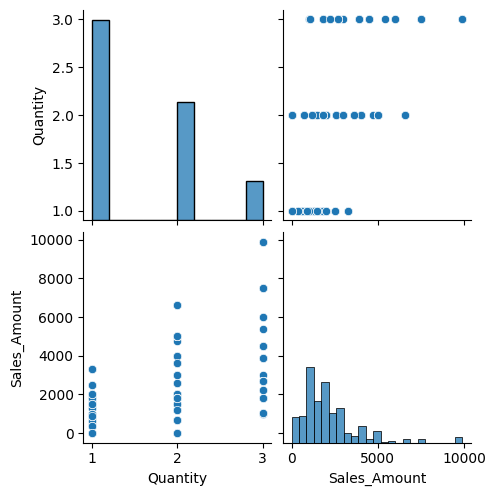

In [0]:
%python
%uv pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
numeric_df = order_df_june_aug_df[['Quantity', 'Sales_Amount']]
sns.pairplot(numeric_df, diag_kind='hist')
plt.show()

In [0]:
%python
import numpy as np

counts, bins = np.histogram(order_df_june_aug_df['Sales_Amount'], bins='auto')

print('Bin ranges and number of values:')
for i in range(len(counts)):
    print(f'{bins[i]:.0f} - {bins[i+1]:.0f} : {counts[i]} values')

Bin ranges and number of values:
0 - 430 : 32 values
430 - 861 : 34 values
861 - 1291 : 96 values
1291 - 1721 : 53 values
1721 - 2152 : 76 values
2152 - 2582 : 37 values
2582 - 3012 : 44 values
3012 - 3442 : 12 values
3442 - 3873 : 8 values
3873 - 4303 : 21 values
4303 - 4733 : 5 values
4733 - 5164 : 14 values
5164 - 5594 : 1 values
5594 - 6024 : 2 values
6024 - 6455 : 0 values
6455 - 6885 : 5 values
6885 - 7315 : 0 values
7315 - 7745 : 5 values
7745 - 8176 : 0 values
8176 - 8606 : 0 values
8606 - 9036 : 0 values
9036 - 9467 : 0 values
9467 - 9897 : 7 values


In [0]:
%python
max_idx = counts.argmax()

print('Most populated bin:', bins[max_idx], '-', bins[max_idx + 1])
print('Number of values:', counts[max_idx])

Most populated bin: 860.6086956521739 - 1290.9130434782608
Number of values: 96


In [0]:
%python
order_df_june_aug_df['Quantity'].corr(order_df_june_aug_df['Sales_Amount'])

np.float64(0.5809391463544905)

### Distribution & Relationship Summary

* **Quantity:** Most orders have a quantity of **1**, while quantity **3** has the lowest count.
* **Sales Amount:** The distribution is **positively/right-skewed** — most values are concentrated on the lower side, with a few high-value sales extending toward **10,000**.
* The most populated Sales Amount bin is **861–1,291**, containing **96 values**.
* The scatter plot does not show a clear relationship between **Sales Amount and Quantity**, suggesting **little to no linear correlation** between the two variables.
* Overall, the data is concentrated around lower sales values with a small number of high-value observations.
